In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
from optimization_script import run_optimization
import stim
import random

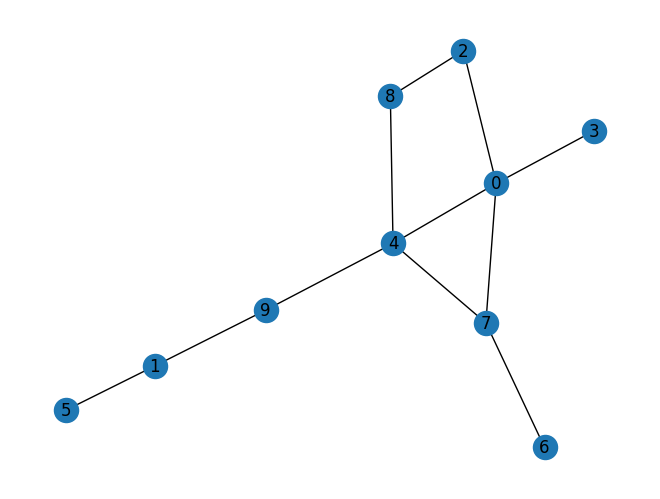

In [35]:
#use this function to generate connected erdos renyi graphs the default erdos renyi generator may produce disconnected graphs
def connected_erdos_renyi_graph(n, p, seed=None, max_tries=10000):
    """
    Generate a connected Erdős–Rényi random graph G(n, p).
    Retries until the generated graph is connected.

    Parameters
    ----------
    n : int
        Number of nodes.
    p : float
        Probability for edge creation.
    seed : int or None, optional
        Random seed for reproducibility.
    max_tries : int, optional
        Maximum number of attempts before giving up.

    Returns
    -------
    G : networkx.Graph
        A connected Erdős–Rényi graph.

    Raises
    ------
    RuntimeError
        If no connected graph is found after max_tries attempts.
    """
    rng = random.Random(seed)
    for _ in range(max_tries):
        # Generate a new random graph using a different seed each time
        current_seed = rng.randrange(1_000_000_000)
        G = nx.erdos_renyi_graph(n, p, seed=current_seed)
        if nx.is_connected(G):
            return G
    raise RuntimeError(f"Failed to generate a connected graph after {max_tries} attempts.")


G = connected_erdos_renyi_graph(10, 0.1, seed=42)
nx.draw(G, with_labels=True)


In [36]:
#create sample
n = 6 # number of nodes
p = 0.5 # probability of edge creation
num_samples = 100 # number of samples to generate
seed = 42 # random seed for reproducibility

# Generate 100 connected graphs
graphs = [connected_erdos_renyi_graph(n, p, seed + i) for i in range(num_samples)]

print(f"Generated {len(graphs)} connected graphs with {n} vertices and p={p}.")
print("All connected:", all(nx.is_connected(G) for G in graphs))

# g = graphs[0]
# nx.draw(g, with_labels=True)

Generated 100 connected graphs with 6 vertices and p=0.5.
All connected: True


In [50]:
# Parameters
n = 13
num_samples = 100
probabilities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6 , 0.7, 0.8 , 0.9, 1.0 ]  # 0.1 to 1.0
seed = 42

# Dictionary to store graphs for each p
graphs_by_p = {}

for p in probabilities:
    print(f"Generating {num_samples} connected graphs for p={p}")
    graphs_by_p[p] = [connected_erdos_renyi_graph(n, p, seed + i) for i in range(num_samples)]

print("\nDone! Summary:")
for p, graphs in graphs_by_p.items():
    print(f"p = {p:.1f} → {len(graphs)} connected graphs")

Generating 100 connected graphs for p=0.1
Generating 100 connected graphs for p=0.2
Generating 100 connected graphs for p=0.3
Generating 100 connected graphs for p=0.4
Generating 100 connected graphs for p=0.5
Generating 100 connected graphs for p=0.6
Generating 100 connected graphs for p=0.7
Generating 100 connected graphs for p=0.8
Generating 100 connected graphs for p=0.9
Generating 100 connected graphs for p=1.0

Done! Summary:
p = 0.1 → 100 connected graphs
p = 0.2 → 100 connected graphs
p = 0.3 → 100 connected graphs
p = 0.4 → 100 connected graphs
p = 0.5 → 100 connected graphs
p = 0.6 → 100 connected graphs
p = 0.7 → 100 connected graphs
p = 0.8 → 100 connected graphs
p = 0.9 → 100 connected graphs
p = 1.0 → 100 connected graphs


In [51]:
# Create a new dictionary to store mean and std for each p
edge_stats_by_p = {}

for p, graphs in graphs_by_p.items():
    num_edges = [G.number_of_edges() for G in graphs]
    mean_edges = np.mean(num_edges)
    std_edges = np.std(num_edges)
    edge_stats_by_p[p] = {
        "mean": mean_edges,
        "std": std_edges,
        "num_graphs": len(graphs)
    }

# Print summary
print("Edge statistics by probability:\n")
for p, stats in edge_stats_by_p.items():
    print(f"p = {p:.1f} → mean edges = {stats['mean']:.2f}, std = {stats['std']:.2f}")

Edge statistics by probability:

p = 0.1 → mean edges = 14.10, std = 1.38
p = 0.2 → mean edges = 17.77, std = 2.96
p = 0.3 → mean edges = 24.55, std = 3.52
p = 0.4 → mean edges = 31.94, std = 4.09
p = 0.5 → mean edges = 39.54, std = 4.05
p = 0.6 → mean edges = 46.46, std = 3.89
p = 0.7 → mean edges = 54.75, std = 3.76
p = 0.8 → mean edges = 62.69, std = 3.53
p = 0.9 → mean edges = 70.66, std = 2.65
p = 1.0 → mean edges = 78.00, std = 0.00


In [52]:
p = 0.6
graphs = graphs_by_p[p]

# Get number of edges for each graph
num_edges = [G.number_of_edges() for G in graphs]

# Compute mean and standard deviation
mean_edges = np.mean(num_edges)
std_edges = np.std(num_edges)

print(f"For p = {p}:")
print(f"Mean number of edges = {mean_edges:.2f}")
print(f"Standard deviation   = {std_edges:.2f}")


For p = 0.6:
Mean number of edges = 46.46
Standard deviation   = 3.89


In [53]:
edge_stats_by_p[0.1]

{'mean': np.float64(14.1),
 'std': np.float64(1.3820274961085255),
 'num_graphs': 100}

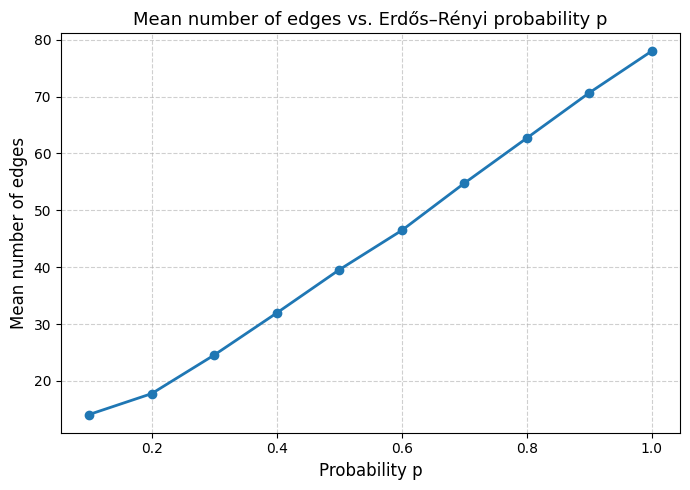

In [54]:
#plot the originlal edge statistics

# Extract data for plotting
ps = sorted(edge_stats_by_p.keys())
mean_edges = [edge_stats_by_p[p]["mean"] for p in ps]

# Plot mean number of edges vs probability
plt.figure(figsize=(7, 5))
plt.plot(ps, mean_edges, marker='o', linestyle='-', linewidth=2)
plt.xlabel("Probability p", fontsize=12)
plt.ylabel("Mean number of edges", fontsize=12)
plt.title("Mean number of edges vs. Erdős–Rényi probability p", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [55]:
#use the edge reduction Nils has
def check_edge_reduction(our_graph_original):
    our_graph_original
    # Create a mapping dictionary: (0, 0) -> 0, (0, 1) -> 1, ..., (2, 2) -> 8
    mapping = {node: i for i, node in enumerate(our_graph_original.nodes())}

    # Create a new graph with integer labels
    our_graph = nx.relabel_nodes(our_graph_original, mapping)
    graph , circ, statistics = run_optimization(our_graph, edge_reduction=True, minLA=False, opt_CNOT= False)
    return graph

In [56]:
# New dictionary to store the reduced-edge graphs
reduced_graphs_by_p = {}

for p, graph_list in graphs_by_p.items():
    print(f"Processing graphs for p={p}...")
    reduced_graphs = [check_edge_reduction(G) for G in graph_list]
    reduced_graphs_by_p[p] = reduced_graphs

print("All graphs processed and stored in reduced_graphs_by_p.")

Processing graphs for p=0.1...
Processing graphs for p=0.2...
Processing graphs for p=0.3...
Processing graphs for p=0.4...
Processing graphs for p=0.5...
Processing graphs for p=0.6...
Processing graphs for p=0.7...
Processing graphs for p=0.8...
Processing graphs for p=0.9...
Processing graphs for p=1.0...
All graphs processed and stored in reduced_graphs_by_p.


In [57]:
# Dictionary to store edge statistics for reduced graphs
reduced_edge_stats_by_p = {}

for p, graphs in reduced_graphs_by_p.items():
    num_edges = [G.number_of_edges() for G in graphs]
    mean_edges = np.mean(num_edges)
    std_edges = np.std(num_edges)
    reduced_edge_stats_by_p[p] = {
        "mean": mean_edges,
        "std": std_edges,
        "num_graphs": len(graphs)
    }

# Print summary
print("Reduced graph edge statistics by probability:\n")
for p, stats in reduced_edge_stats_by_p.items():
    print(f"p = {p:.1f} → mean edges = {stats['mean']:.2f}, std = {stats['std']:.2f}")


Reduced graph edge statistics by probability:

p = 0.1 → mean edges = 13.79, std = 1.42
p = 0.2 → mean edges = 16.95, std = 2.96
p = 0.3 → mean edges = 22.75, std = 3.18
p = 0.4 → mean edges = 27.64, std = 3.58
p = 0.5 → mean edges = 30.18, std = 3.48
p = 0.6 → mean edges = 30.18, std = 2.82
p = 0.7 → mean edges = 28.24, std = 3.01
p = 0.8 → mean edges = 22.52, std = 4.17
p = 0.9 → mean edges = 14.97, std = 2.34
p = 1.0 → mean edges = 12.00, std = 0.00


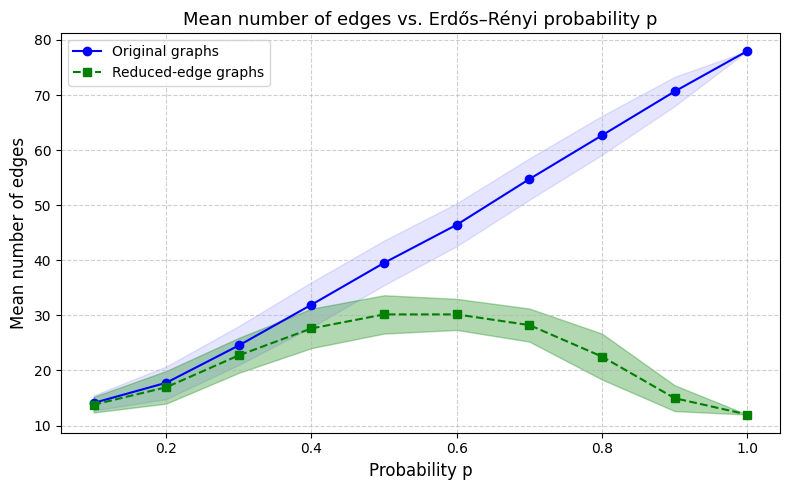

In [58]:
import matplotlib.pyplot as plt

# Probabilities (sorted)
ps = sorted(edge_stats_by_p.keys())

# Mean and standard deviation for original graphs
mean_edges_original = [edge_stats_by_p[p]["mean"] for p in ps]
std_edges_original = [edge_stats_by_p[p]["std"] for p in ps]

# Mean and standard deviation for reduced graphs
mean_edges_reduced = [reduced_edge_stats_by_p[p]["mean"] for p in ps]
std_edges_reduced = [reduced_edge_stats_by_p[p]["std"] for p in ps]

plt.figure(figsize=(8, 5))

# Original graphs: mean + shaded std
plt.plot(ps, mean_edges_original, marker='o', linestyle='-', color='blue', label='Original graphs')
plt.fill_between(
    ps,
    [m - s for m, s in zip(mean_edges_original, std_edges_original)],
    [m + s for m, s in zip(mean_edges_original, std_edges_original)],
    color='blue', alpha=0.1
)

# Reduced-edge graphs: mean + shaded std
plt.plot(ps, mean_edges_reduced, marker='s', linestyle='--', color='green', label='Reduced-edge graphs')
plt.fill_between(
    ps,
    [m - s for m, s in zip(mean_edges_reduced, std_edges_reduced)],
    [m + s for m, s in zip(mean_edges_reduced, std_edges_reduced)],
    color='green', alpha=0.3
)

plt.xlabel("Probability p", fontsize=12)
plt.ylabel("Mean number of edges", fontsize=12)
plt.title("Mean number of edges vs. Erdős–Rényi probability p", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


#### Same process for new Edge Reduction Paper (Commented out as it takes much time to calculate)

In [ ]:
# from edge_reduction_graph_state_optimization import graphstate_opt as gso
# import time as time# 

In [2]:
# #parameters maximum iterations and temperature for the SA algorithm
# kmax = 100
# temperature = 100

# # defining the input graph as networkx complete graph
# Gprev = nx.grid_graph(dim=(4,5))

# mapping = {node: i for i, node in enumerate(Gprev.nodes())}

# # Create a new graph with integer labels
# relabel_initial_graph = nx.relabel_nodes(Gprev, mapping)

# #nx.complete_graph(5) #

# #graphs_by_p[0.3][0]  

# # calling and giving the graph G as the input to SA+ILP and ILP
# # the function returns graphs obtained from SA and SA+ILP. 
# # and the runtime of ILP and SA+ILP
# output = gso.edm_sa_ilp(relabel_initial_graph, kmax, temperature)

# #output graph from SA+ILP of the algorithm
# gout_sailp = output[0]
# # output graph from SA part
# gout_sa = output[1]

# #the runtimes for SA+ILP and ILP
# sailp_runtime = output[4]
# ilp_runtime = output[5]
# print("SA_ILP runtime =", sailp_runtime)
# print("ILP runtime =", ilp_runtime)

# plt.figure()
# plt.title("Input graph")
# nx.draw_networkx(Gprev)
# plt.draw()
# plt.show(block=False)

# plt.figure()
# plt.title("Graph from SA")
# nx.draw_networkx(gout_sa)
# plt.draw()
# plt.show(block=False)


# plt.figure()
# plt.title("Graph from SA+ILP")
# nx.draw_networkx(gout_sailp)
# plt.draw()
# plt.show(block=False)

In [3]:
# # Dictionaries to store the graphs
# sailp_graphs_by_p = {}
# sa_graphs_by_p = {}
# kmax = 100
# temperature = 100


# for p, graph_list in graphs_by_p.items():
#     print(f"Processing graphs for p={p} with SA+ILP and SA...")
    
#     sailp_graphs = []
#     sa_graphs = []
    
#     for G in graph_list:
#         output = gso.edm_sa_ilp(G, kmax, temperature)  # your function
#         # extract the first two elements
#         gout_sailp = output[0]
#         gout_sa = output[1]
        
#         sailp_graphs.append(gout_sailp)
#         sa_graphs.append(gout_sa)
    
#     sailp_graphs_by_p[p] = sailp_graphs
#     sa_graphs_by_p[p] = sa_graphs

# print("All graphs processed and stored in sailp_graphs_by_p and sa_graphs_by_p.")